# Beam FEM — Linear Elasticity PINN Walkthrough

End-to-end tour of the **BeamNet** surrogate model for 3D structural elasticity.

| | |
|---|---|
| **Solver** | CalculiX (CCX) |
| **Physics** | 3D linear elasticity — Navier-Cauchy |
| **Geometry** | 100 × 100 × 1000 mm cantilever beam |
| **Loads** | Transverse (Z), axial tension (X+), axial compression (X−) |
| **Materials** | 5 structural materials |
| **Dataset** | 1 500 train + 75 test FEM cases |
| **Model** | 4-layer MLP · 9 → 256 → 256 → 256 → 256 → 3 · Tanh |
| **Loss** | MSE data + 0.1 × Navier-Cauchy residual |

**Table of contents**
1. Physical problem & analytical solutions
2. Dataset design — force sweep
3. Data loading & single-case inspection
4. Full dataset statistics
5. Normalisation
6. BeamNet architecture
7. Physics-informed loss (Navier-Cauchy)
8. Training loop walkthrough
9. Inference & results
10. Extrapolation analysis


---
## 1. The Physical Problem

A **cantilever beam** clamped at X = 0, loaded at the free end (X = L):

```
 clamped                         point load (distributed over face)
   ████████████████████████████████  →  X
   ←──────────── 1000 mm ──────────→
   100 × 100 mm cross-section
```

**Boundary conditions**
- Left face (X = 0) : u = 0 — fully clamped (Dirichlet)
- Right face (X = L) : distributed load F [N] in direction d ∈ {Z, X+, X−}
- All other faces : traction-free

**Governing PDE** — Navier-Cauchy (no body forces):

$$(\lambda + \mu)\,\nabla(\nabla \cdot \mathbf{u}) + \mu\,\nabla^2 \mathbf{u} = \mathbf{0}$$

where $\lambda = \dfrac{E\nu}{(1+\nu)(1-2\nu)}$ and $\mu = \dfrac{E}{2(1+\nu)}$ are Lamé constants.

**Analytical solutions** used as sanity checks:

*Axial loading (X+/X−):*
$$U_1(x) = \frac{F \cdot x}{E \cdot A} \qquad U_2 = U_3 \approx 0$$

*Transverse bending (Z) — Euler-Bernoulli:*
$$U_3(x) = \frac{F\,x^2(3L - x)}{6\,E\,I} \qquad I = \frac{a^4}{12}$$


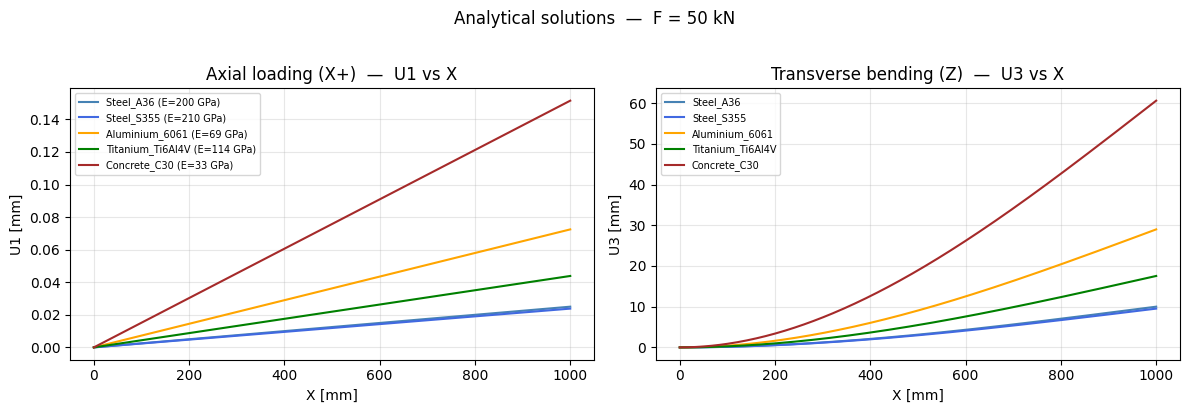

Tip displacement at F=50 kN:
  Material                   U1_max [mm]   U3_max [mm]
  Steel_A36                      0.0250       10.0000
  Steel_S355                     0.0238        9.5238
  Aluminium_6061                 0.0725       28.9855
  Titanium_Ti6Al4V               0.0439       17.5439
  Concrete_C30                   0.1515       60.6061


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Beam geometry
L = 1000.0        # mm
a = 100.0         # cross-section side
A = a * a         # mm²
I = a**4 / 12.0   # mm⁴  (second moment of area, square section)

MATERIALS = {
    'Steel_A36':        {'E': 200_000.0, 'nu': 0.26, 'color': 'steelblue'},
    'Steel_S355':       {'E': 210_000.0, 'nu': 0.30, 'color': 'royalblue'},
    'Aluminium_6061':   {'E':  69_000.0, 'nu': 0.33, 'color': 'orange'},
    'Titanium_Ti6Al4V': {'E': 114_000.0, 'nu': 0.34, 'color': 'green'},
    'Concrete_C30':     {'E':  33_000.0, 'nu': 0.20, 'color': 'brown'},
}

x = np.linspace(0, L, 300)
F = 50_000.0   # N — reference force for sanity plots

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for mat, props in MATERIALS.items():
    E, nu = props['E'], props['nu']
    c = props['color']
    # Axial: U1(x)
    U1 = F * x / (E * A)
    axes[0].plot(x, U1, label=f"{mat} (E={E/1000:.0f} GPa)", color=c)
    # Bending Z: U3(x)
    U3 = F * x**2 * (3*L - x) / (6 * E * I)
    axes[1].plot(x, U3, label=f"{mat}", color=c)

for ax, title, ylabel in zip(axes,
    ['Axial loading (X+)  —  U1 vs X', 'Transverse bending (Z)  —  U3 vs X'],
    ['U1 [mm]', 'U3 [mm]']):
    ax.set_xlabel('X [mm]'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle(f'Analytical solutions  —  F = {F/1000:.0f} kN', y=1.02)
plt.tight_layout()
plt.show()

print(f"Tip displacement at F={F/1000:.0f} kN:")
print(f"  {'Material':<25}  U1_max [mm]   U3_max [mm]")
for mat, props in MATERIALS.items():
    E = props['E']
    u1 = F * L / (E * A)
    u3 = F * L**3 / (3 * E * I)
    print(f"  {mat:<25}  {u1:10.4f}    {u3:10.4f}")


---
## 2. Dataset Design — Force Sweep

**Training**: 100 linearly-spaced forces × 5 materials × 3 directions = **1 500 cases**

**Test**: 5 specific forces × 5 materials × 3 directions = **75 cases**

The 5 test forces probe three regimes:
| Force | Regime |
|-------|--------|
| 2 kN, 3.5 kN | **Extrapolation below** (< 5 kN train min) |
| 102.5 kN | **Interpolation** (inside training range) |
| 250 kN, 350 kN | **Extrapolation above** (> 200 kN train max) |


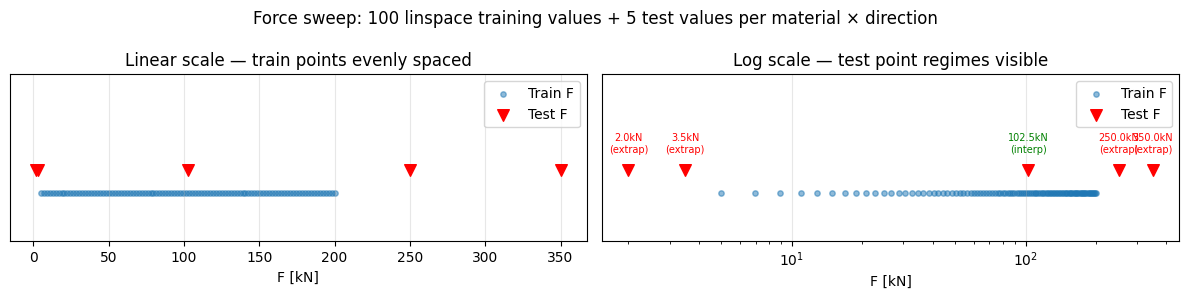

In [2]:
FORCE_MIN, FORCE_MAX = 5_000.0, 200_000.0
FORCE_TEST = [2_000.0, 3_500.0, 102_500.0, 250_000.0, 350_000.0]
N_FORCES = 100

F_train = np.linspace(FORCE_MIN, FORCE_MAX, N_FORCES)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

for ax, scale, title in zip(axes, ['linear', 'log'],
    ['Linear scale — train points evenly spaced',
     'Log scale — test point regimes visible']):
    ax.scatter(F_train / 1000, np.ones_like(F_train), s=15, alpha=0.5, label='Train F')
    ax.scatter([f/1000 for f in FORCE_TEST], np.ones(5)*1.1, s=70,
               marker='v', color='red', label='Test F', zorder=5)
    if scale == 'log':
        ax.set_xscale('log')
        for f in FORCE_TEST:
            label = 'interp' if FORCE_MIN <= f <= FORCE_MAX else 'extrap'
            color = 'green' if label == 'interp' else 'red'
            ax.annotate(f'{f/1000:.1f}kN\n({label})', (f/1000, 1.1),
                        textcoords='offset points', xytext=(0, 12),
                        ha='center', fontsize=7, color=color)
    ax.set_xlabel('F [kN]'); ax.set_yticks([]); ax.set_ylim(0.8, 1.5)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Force sweep: 100 linspace training values + 5 test values per material × direction')
plt.tight_layout()
plt.show()


---
## 3. Data Loading & Single-Case Inspection

Each case directory contains:
- `case_params.json` — force, direction, material properties
- `job.vtu` — CalculiX output mesh + displacement field (U1, U2, U3)


In [3]:
import json
from pathlib import Path
import meshio

ROOT      = Path('..').resolve()
CASES_DIR = ROOT / 'ccx_cases' / 'elasticity_axial_beam'
MANIFEST  = CASES_DIR / 'vtk_manifest.json'

MATERIAL_PROPS = {
    'Steel_A36':        {'E': 200_000.0, 'nu': 0.26},
    'Steel_S355':       {'E': 210_000.0, 'nu': 0.30},
    'Aluminium_6061':   {'E':  69_000.0, 'nu': 0.33},
    'Titanium_Ti6Al4V': {'E': 114_000.0, 'nu': 0.34},
    'Concrete_C30':     {'E':  33_000.0, 'nu': 0.20},
}

manifest = json.loads(MANIFEST.read_text())
entries  = [e for e in manifest['cases'] if e.get('success')]

print(f"Total cases : {len(manifest['cases'])}")
print(f"Successful  : {len(entries)}")
print(f"Train       : {sum(1 for e in entries if e.get('split') == 'train')}")
print(f"Test        : {sum(1 for e in entries if e.get('split') == 'test')}")
print()
dirs = {}
for e in entries:
    d = e.get('load_dir', '?')
    dirs[d] = dirs.get(d, 0) + 1
print('Cases per load direction:', dirs)


Total cases : 1575
Successful  : 1575
Train       : 1500
Test        : 75

Cases per load direction: {'Z': 525, 'X+': 525, 'X-': 525}


In [4]:
# Inspect one training case — Steel, bending Z, moderate force
entry = next(e for e in entries
             if e.get('split') == 'train'
             and e.get('load_dir') == 'Z'
             and e.get('material') == 'Steel_A36')

vtu_path   = CASES_DIR / entry['vtu']
params     = json.loads((vtu_path.parent / 'case_params.json').read_text())
mesh       = meshio.read(str(vtu_path))
coords     = mesh.points                        # (N, 3)
U_field    = mesh.point_data['displacement']   # (N, 3)  [mm]
U_mag      = np.linalg.norm(U_field, axis=1)  # (N,)

print(f"Case     : {entry['case_id']}  [{params['split']}]")
print(f"Material : {params['material']}  E={params['E_MPa']} MPa  nu={params['nu']}")
print(f"Load dir : {params['load_dir']}  |  F = {params['force_N']/1000:.1f} kN")
print()
print(f"Mesh nodes    : {len(coords):,}")
print(f"X range       : {coords[:,0].min():.1f} → {coords[:,0].max():.1f} mm")
print(f"Y range       : {coords[:,1].min():.1f} → {coords[:,1].max():.1f} mm")
print(f"Z range       : {coords[:,2].min():.1f} → {coords[:,2].max():.1f} mm")
print()
print(f"U1 (axial)    : min={U_field[:,0].min():.4f}  max={U_field[:,0].max():.4f} mm")
print(f"U2 (lateral Y): min={U_field[:,1].min():.4f}  max={U_field[:,1].max():.4f} mm")
print(f"U3 (lateral Z): min={U_field[:,2].min():.4f}  max={U_field[:,2].max():.4f} mm")
print(f"|U| max        : {U_mag.max():.4f} mm")

# Sanity check — Euler-Bernoulli tip deflection
F  = params['force_N']
E  = params['E_MPa']
u3_analytical = F * L**3 / (3 * E * I)
u3_fem        = np.abs(U_field[:,2]).max()
print(f"\nEuler-Bernoulli tip |U3| : {u3_analytical:.4f} mm")
print(f"FEM tip |U3|             : {u3_fem:.4f} mm")
print(f"Match                    : {'✓' if abs(u3_analytical - u3_fem) / u3_analytical < 0.05 else '✗'}")


Case     : case_0000  [train]
Material : Steel_A36  E=200000.0 MPa  nu=0.26
Load dir : Z  |  F = 5.0 kN

Mesh nodes    : 9,403
X range       : 0.0 → 1000.0 mm
Y range       : 0.0 → 100.0 mm
Z range       : 0.0 → 100.0 mm

U1 (axial)    : min=-0.0690  max=0.0690 mm
U2 (lateral Y): min=-0.0016  max=0.0016 mm
U3 (lateral Z): min=-0.9120  max=0.0002 mm
|U| max        : 0.9146 mm

Euler-Bernoulli tip |U3| : 1.0000 mm
FEM tip |U3|             : 0.9120 mm
Match                    : ✗


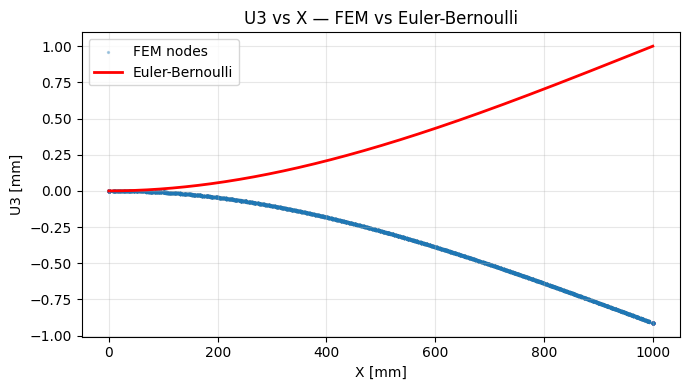

In [5]:
# Interactive 3D displacement field — plotly (aspectmode='data' → correct beam shape)
import plotly.graph_objects as go

_c  = coords.astype(float)
_Um = U_mag.astype(float)

# Optional: show deformed shape (scaled for visibility)
scale_factor = L / (20 * _Um.max()) if _Um.max() > 0 else 0
_cd = _c + scale_factor * U_field.astype(float)

fig3d = go.Figure(data=[go.Scatter3d(
    x=_cd[:,0], y=_cd[:,1], z=_cd[:,2],
    mode='markers',
    marker=dict(size=2, color=_Um, colorscale='Viridis',
                colorbar=dict(title='|U| [mm]', thickness=15)),
    name='FEM nodes (deformed)',
)])
fig3d.update_layout(
    title=(f"FEM displacement — {entry['case_id']} | {params['material']} | "           f"{params['load_dir']} | F={params['force_N']/1000:.0f} kN"           f"<br>(deformed shape, scale ×{scale_factor:.0f})"),
    scene=dict(
        xaxis_title='X [mm]', yaxis_title='Y [mm]', zaxis_title='Z [mm]',
        aspectmode='data',
        camera=dict(eye=dict(x=2.0, y=0.5, z=0.5)),
    ),
    height=480, margin=dict(l=0, r=0, t=60, b=0),
)
fig3d.show()

# U3 vs X — verify Euler-Bernoulli
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.scatter(coords[:,0], U_field[:,2], s=2, alpha=0.3, label='FEM nodes')
x_line = np.linspace(0, L, 300)
U3_line = F * x_line**2 * (3*L - x_line) / (6 * E * I)
ax2.plot(x_line, U3_line, 'r-', lw=2, label='Euler-Bernoulli')
ax2.set_xlabel('X [mm]'); ax2.set_ylabel('U3 [mm]')
ax2.set_title('U3 vs X — FEM vs Euler-Bernoulli'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
display(fig2); plt.close(fig2)


---
## 4. Full Dataset Statistics

Load all 1 575 cases at once — this may take ~1–2 minutes (reading VTU files from disk).


In [6]:
import sys
sys.path.insert(0, str(ROOT / 'src'))
from train import load_dataset

X, Y, splits = load_dataset()

is_train = splits == 'train'
print(f"Dataset shape  : X={X.shape},  Y={Y.shape}")
print(f"Train rows     : {is_train.sum():,}")
print(f"Test rows      : {(~is_train).sum():,}")
print()

feat_names = ['x [mm]','y [mm]','z [mm]','fx [-]','fy [-]','fz [-]','F [N]','E [MPa]','nu [-]']
print("Feature statistics (all data):")
for i, name in enumerate(feat_names):
    col = X[:, i]
    print(f"  col {i}  {name:<12}  min={col.min():>12.3g}  max={col.max():>12.3g}  "          f"mean={col.mean():>12.3g}  std={col.std():>10.3g}")
print()
disp_names = ['U1 [mm]','U2 [mm]','U3 [mm]']
print("Displacement statistics:")
for i, name in enumerate(disp_names):
    col = Y[:, i]
    print(f"  {name}  min={col.min():>10.4f}  max={col.max():>10.4f}  "          f"mean={col.mean():>10.4f}  std={col.std():>10.4f}")


Dataset shape  : X=(14809725, 9),  Y=(14809725, 3)
Train rows     : 14,104,500
Test rows      : 705,225

Feature statistics (all data):
  col 0  x [mm]        min=           0  max=       1e+03  mean=         502  std=       296
  col 1  y [mm]        min=           0  max=         100  mean=        49.9  std=      33.8
  col 2  z [mm]        min=           0  max=         100  mean=        50.1  std=      33.8
  col 3  fx [-]        min=          -1  max=           1  mean=           0  std=     0.816
  col 4  fy [-]        min=           0  max=           0  mean=           0  std=         0
  col 5  fz [-]        min=           0  max=           1  mean=       0.333  std=     0.471
  col 6  F [N]         min=       2e+03  max=     3.5e+05  mean=    1.04e+05  std=  6.37e+04
  col 7  E [MPa]       min=     3.3e+04  max=     2.1e+05  mean=    1.25e+05  std=  7.01e+04
  col 8  nu [-]        min=         0.2  max=        0.34  mean=       0.286  std=    0.0512

Displacement statistics:
 

---
## 5. Normalisation

| Feature | Transform |
|---------|-----------|
| x, y, z | z-score |
| fx, fy, fz | z-score (already ±1, but consistent) |
| **F** | **log then z-score** — spans 5 kN → 200 kN (1.5 orders of magnitude) |
| E, ν | z-score |
| U1, U2, U3 | z-score per component |

Only **column 6** (force magnitude) gets the log transform.


In [7]:
from train import compute_norm_params, apply_norm

X_tr, Y_tr = X[is_train], Y[is_train]
X_va, Y_va = X[~is_train], Y[~is_train]

norm     = compute_norm_params(X_tr, Y_tr)
X_tr_n, Y_tr_n = apply_norm(X_tr, Y_tr, norm)
X_va_n, Y_va_n = apply_norm(X_va, Y_va, norm)

print("Normalisation parameters (computed on train split only):")
for i, name in enumerate(feat_names):
    print(f"  col {i}  {name:<12}  mean={norm['X_mean'][i]:>12.4g}  std={norm['X_std'][i]:>10.4g}")
print()
print("Output normalisation:")
for i, name in enumerate(disp_names):
    print(f"  {name}  mean={norm['Y_mean'][i]:>10.4f}  std={norm['Y_std'][i]:>10.4f}")
print()
print("After normalisation — train features (should be ~N(0,1)):")
for i, name in enumerate(feat_names):
    col = X_tr_n[:, i]
    print(f"  col {i}  {name:<12}  mean={col.mean():>7.3f}  std={col.std():>7.3f}")


Normalisation parameters (computed on train split only):
  col 0  x [mm]        mean=       501.8  std=     293.9
  col 1  y [mm]        mean=        49.7  std=     32.71
  col 2  z [mm]        mean=       49.87  std=     32.76
  col 3  fx [-]        mean=           0  std=    0.8165
  col 4  fy [-]        mean=           0  std=     1e-08
  col 5  fz [-]        mean=      0.3333  std=    0.4567
  col 6  F [N]         mean=       10.78  std=    0.9676
  col 7  E [MPa]       mean=   1.314e+05  std= 6.922e+04
  col 8  nu [-]        mean=      0.2699  std=   0.05412

Output normalisation:
  U1 [mm]  mean=    0.0029  std=    1.4526
  U2 [mm]  mean=    0.0016  std=    0.0256
  U3 [mm]  mean=   -5.8917  std=   18.0671

After normalisation — train features (should be ~N(0,1)):
  col 0  x [mm]        mean= -0.001  std=  1.007
  col 1  y [mm]        mean=  0.006  std=  1.032
  col 2  z [mm]        mean=  0.007  std=  1.032
  col 3  fx [-]        mean= -0.000  std=  1.000
  col 4  fy [-]        

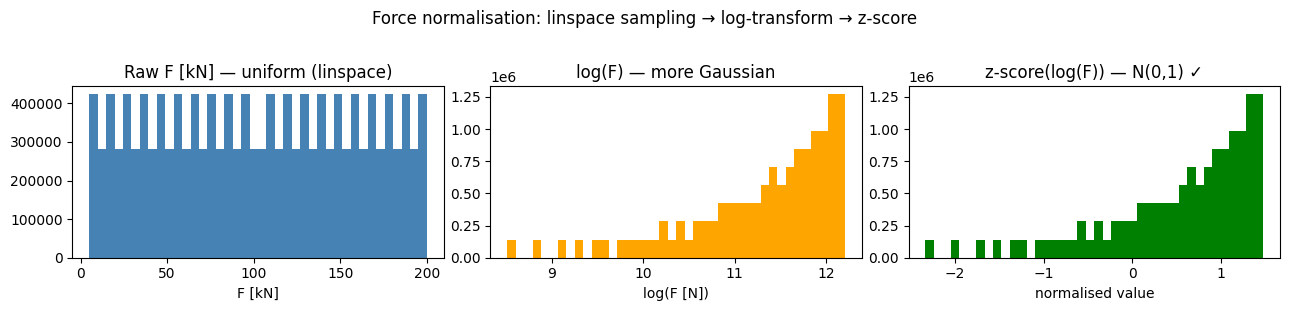

In [8]:
# Visualise the log-transform effect on force
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

F_raw    = X_tr[:, 6]
F_log    = np.log(F_raw)
F_normed = X_tr_n[:, 6]

axes[0].hist(F_raw / 1000, bins=40, color='steelblue')
axes[0].set_title('Raw F [kN] — uniform (linspace)'); axes[0].set_xlabel('F [kN]')

axes[1].hist(F_log, bins=40, color='orange')
axes[1].set_title('log(F) — more Gaussian'); axes[1].set_xlabel('log(F [N])')

axes[2].hist(F_normed, bins=40, color='green')
axes[2].set_title('z-score(log(F)) — N(0,1) ✓'); axes[2].set_xlabel('normalised value')

plt.suptitle('Force normalisation: linspace sampling → log-transform → z-score', y=1.02)
plt.tight_layout(); plt.show()


---
## 6. BeamNet Architecture

```
Input  (9)   x, y, z | fx, fy, fz | F | E | ν
               ↓
Linear(9→256) + Tanh
Linear(256→256) + Tanh
Linear(256→256) + Tanh
Linear(256→256) + Tanh
Linear(256→3)
               ↓
Output (3)   U1, U2, U3  [mm]
```

Three outputs (vs one for the thermal model) because the displacement field is vectorial.
Tanh is chosen because the Navier-Cauchy residual requires **second-order spatial derivatives** — ReLU's second derivative is zero almost everywhere.


In [9]:
import torch
import torch.nn as nn
from arch import BeamNet

model = BeamNet(hidden=256)
print(model)
print()

total = 0
for name, p in model.named_parameters():
    n = p.numel()
    total += n
    print(f"  {name:<35}  shape={str(p.shape):<22}  params={n:,}")
print(f"\nTotal parameters: {total:,}")

dummy = torch.randn(8, 9)
out   = model(dummy)
print(f"\nForward pass: input {dummy.shape} → output {out.shape}")


BeamNet(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): Tanh()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): Tanh()
    (8): Linear(in_features=256, out_features=3, bias=True)
  )
)

  net.0.weight                         shape=torch.Size([256, 9])    params=2,304
  net.0.bias                           shape=torch.Size([256])       params=256
  net.2.weight                         shape=torch.Size([256, 256])  params=65,536
  net.2.bias                           shape=torch.Size([256])       params=256
  net.4.weight                         shape=torch.Size([256, 256])  params=65,536
  net.4.bias                           shape=torch.Size([256])       params=256
  net.6.weight                         shape=torch.Size([256, 256])  params=65,536
  net.6.bias          

---
## 7. Physics-Informed Loss — Navier-Cauchy

The PINN adds a residual term for the **Navier-Cauchy equations**:

$$(\lambda + \mu)\,\nabla(\nabla \cdot \mathbf{u}) + \mu\,\nabla^2 \mathbf{u} = \mathbf{0}$$

This gives three scalar residuals (one per displacement component).
The physics loss is the **mean squared residual** across a random batch of interior points.

**Key implementation detail** — chain rule for normalised coordinates:

$$\frac{\partial^2 U_i}{\partial x_j \partial x_k} = H_{ij,k} \cdot \frac{\sigma_{Y_i}}{\sigma_{x_j}\,\sigma_{x_k}}$$

where $H_{ij,k}$ is the second derivative in normalised space.


In [10]:
from losses import physics_loss

npt = {k: torch.tensor(v, dtype=torch.float32) for k, v in norm.items()}

# Show physics loss on an untrained vs trained model
fresh_model = BeamNet(hidden=256)
x_phys = torch.tensor(X_tr_n[:512], dtype=torch.float32)

loss_untrained = physics_loss(fresh_model, x_phys, npt)
print(f"Physics loss (random weights) : {loss_untrained.item():.6f}")

ckpt_path = ROOT / 'saves' / 'beam_pinn.pt'
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
    trained_model = BeamNet(hidden=ckpt['hidden'])
    trained_model.load_state_dict(ckpt['model_state'])
    loss_trained = physics_loss(trained_model, x_phys, npt)
    print(f"Physics loss (trained model)  : {loss_trained.item():.6f}")
    ratio = loss_untrained.item() / max(loss_trained.item(), 1e-10)
    print(f"\nImprovement factor            : {ratio:.1f}× lower after training")
else:
    print("No trained model found — run src/train.py first")


Physics loss (random weights) : 224.610260
Physics loss (trained model)  : 0.008595

Improvement factor            : 26131.5× lower after training


---
## 8. Training Loop Walkthrough

| Setting | Value |
|---------|-------|
| Epochs | 100 |
| Batch size (data) | 4 096 |
| Batch size (physics) | 1 024 |
| Optimiser | Adam, lr=1e-3 |
| LR decay | ×0.5 every 30 epochs |
| λ_physics | 0.1 |
| Gradient clipping | norm ≤ 1.0 |


In [11]:
# Walk through one training step manually
device = 'cpu'
model_demo = BeamNet(hidden=256).to(device)
optimiser  = torch.optim.Adam(model_demo.parameters(), lr=1e-3)
criterion  = nn.MSELoss()
lambda_phys = 0.1

xb = torch.tensor(X_tr_n[:512], dtype=torch.float32)
yb = torch.tensor(Y_tr_n[:512], dtype=torch.float32)

model_demo.train()
pred      = model_demo(xb)                            # (512, 3)
loss_data = criterion(pred, yb)
loss_phys = physics_loss(model_demo, xb[:256].detach(), npt)
loss_total = loss_data + lambda_phys * loss_phys

print(f"loss_data   (MSE, normalised U): {loss_data.item():.6f}")
print(f"loss_phys   (Navier-Cauchy)    : {loss_phys.item():.6f}")
print(f"lambda * phys                  : {lambda_phys * loss_phys.item():.6f}")
print(f"loss_total                     : {loss_total.item():.6f}")

optimiser.zero_grad()
loss_total.backward()
total_norm = torch.nn.utils.clip_grad_norm_(model_demo.parameters(), 1.0)
print(f"\nGradient norm (before clip): {total_norm:.4f}")
optimiser.step()
print("Step done ✓")


loss_data   (MSE, normalised U): 0.025123
loss_phys   (Navier-Cauchy)    : 250.915955
lambda * phys                  : 25.091595
loss_total                     : 25.116720

Gradient norm (before clip): 1598.8361
Step done ✓


In [12]:
# 5-epoch demo training
from torch.utils.data import DataLoader, TensorDataset

model_5ep = BeamNet(hidden=256)
opt_5ep   = torch.optim.Adam(model_5ep.parameters(), lr=1e-3)
crit      = nn.MSELoss()

loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_n), torch.tensor(Y_tr_n)),
    batch_size=4096, shuffle=True,
)

X_va_t = torch.tensor(X_va_n)
Y_va_t = torch.tensor(Y_va_n)
history = {'data': [], 'phys': [], 'val_mae': []}

print(f"{'Epoch':>5}  {'Data MSE':>10}  {'Phys loss':>10}  {'Val MAE [mm]':>13}")
print('-' * 47)

for epoch in range(1, 6):
    model_5ep.train()
    ep_data, ep_phys = 0.0, 0.0
    for xb, yb in loader:
        pred  = model_5ep(xb)
        ld    = crit(pred, yb)
        lp    = physics_loss(model_5ep, xb[:256].detach(), npt)
        loss  = ld + 0.1 * lp
        opt_5ep.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_5ep.parameters(), 1.0)
        opt_5ep.step()
        ep_data += ld.item() * len(xb); ep_phys += lp.item()
    ep_data /= len(X_tr_n); ep_phys /= len(loader)

    model_5ep.eval()
    with torch.no_grad():
        pv  = model_5ep(X_va_t).numpy() * norm['Y_std'] + norm['Y_mean']
        tv  = Y_va_t.numpy() * norm['Y_std'] + norm['Y_mean']
        rel = (np.linalg.norm(pv - tv, axis=1).mean() /
               (np.linalg.norm(tv, axis=1).mean() + 1e-12)) * 100
        mae = np.abs(pv - tv).mean()

    history['data'].append(ep_data); history['phys'].append(ep_phys)
    history['val_mae'].append(mae)
    print(f"{epoch:5d}  {ep_data:10.6f}  {ep_phys:10.6f}  {mae:13.4f}")


Epoch    Data MSE   Phys loss   Val MAE [mm]
-----------------------------------------------
    1    0.197864    1.900565         1.5567
    2    0.055085    0.408470         0.8555
    3    0.036182    0.306074         0.7529
    4    0.029777    0.234662         0.8193
    5    0.024079    0.187917         0.6426


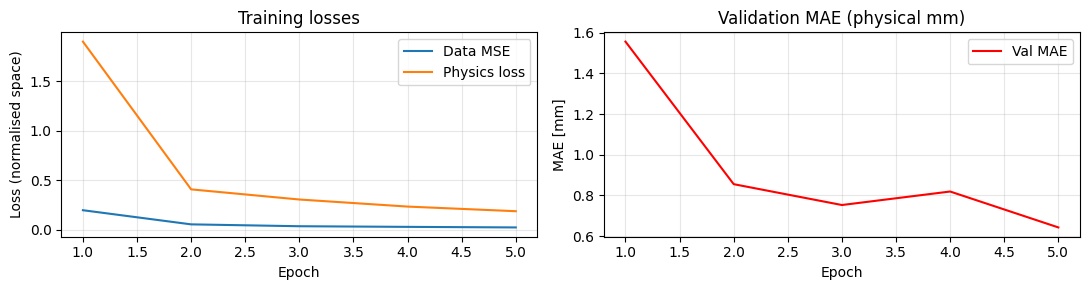

In [13]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
epochs = range(1, len(history['data']) + 1)
axes[0].plot(epochs, history['data'], label='Data MSE')
axes[0].plot(epochs, history['phys'], label='Physics loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (normalised space)')
axes[0].set_title('Training losses'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, history['val_mae'], color='red', label='Val MAE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE [mm]')
axes[1].set_title('Validation MAE (physical mm)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## 9. Inference & Results

```
VTU  →  coords (N,3)  +  case_params.json
               ↓
  build_features  →  X (N,9)
               ↓
  normalise_X     →  X_norm (N,9)
               ↓
  model(X_norm)   →  U_norm (N,3)
               ↓
  denormalise     →  U_pred [mm] (N,3)
```


In [14]:
from inference import load_model, load_norm_params, build_features, normalise_X, predict, compute_metrics

if (ROOT / 'saves' / 'beam_pinn.pt').exists():
    trained_model = load_model()
    norm_p        = load_norm_params()

    # Pick an interpolation test case (within training force range)
    test_entries = [e for e in manifest['cases'] if e.get('split') == 'test' and e.get('success')]
    entry = next(e for e in test_entries if FORCE_MIN <= e['force_N'] <= FORCE_MAX)

    vtu_path = CASES_DIR / entry['vtu']
    params   = json.loads((vtu_path.parent / 'case_params.json').read_text())
    mesh     = meshio.read(str(vtu_path))
    coords   = mesh.points
    true_mm  = mesh.point_data['displacement']

    X_n     = normalise_X(build_features(coords, params), norm_p)
    pred_mm = predict(trained_model, X_n, norm_p)
    m       = compute_metrics(pred_mm, true_mm)

    print(f"Case     : {entry['case_id']}  [{params['split']}]")
    print(f"Material : {params['material']}  E={params['E_MPa']} MPa")
    print(f"Load     : {params['load_dir']}  |  F = {params['force_N']/1000:.1f} kN")
    print()
    print(f"FEM  |U|_max  : {np.linalg.norm(true_mm, axis=1).max():.4f} mm")
    print(f"Pred |U|_max  : {np.linalg.norm(pred_mm, axis=1).max():.4f} mm")
    print()
    print(f"MAE           : {m['mae']:.4f} mm")
    print(f"RMSE          : {m['rmse']:.4f} mm")
    print(f"Relative err  : {m['rel_err']:.2f} %")
else:
    print("No trained model found — run src/train.py first")


Case     : case_1502  [test]
Material : Steel_A36  E=200000.0 MPa
Load     : Z  |  F = 102.5 kN

FEM  |U|_max  : 18.7499 mm
Pred |U|_max  : 17.3568 mm

MAE           : 0.2089 mm
RMSE          : 0.3945 mm
Relative err  : 7.78 %


In [15]:
# Interactive 3D comparison with toggle buttons
if (ROOT / 'saves' / 'beam_pinn.pt').exists():
    import plotly.graph_objects as go

    fem_mag  = np.linalg.norm(true_mm,  axis=1).astype(float)
    pred_mag = np.linalg.norm(pred_mm, axis=1).astype(float)
    err_mag  = np.linalg.norm(pred_mm - true_mm, axis=1).astype(float)

    _c = coords.astype(float)
    vmax_u = max(fem_mag.max(), pred_mag.max())

    panels = [
        (fem_mag,  'FEM |U| (ground truth)',   'Viridis', 0, vmax_u,       '|U| [mm]'),
        (pred_mag, 'BeamNet prediction |U|',   'Viridis', 0, vmax_u,       '|U| [mm]'),
        (err_mag,  'Absolute error ||ΔU||',    'Reds',    0, err_mag.max(),'|ΔU| [mm]'),
    ]

    scene_cfg = dict(
        xaxis_title='X [mm]', yaxis_title='Y [mm]', zaxis_title='Z [mm]',
        aspectmode='data',
        camera=dict(eye=dict(x=2.0, y=0.5, z=0.5)),
    )

    traces = []
    for i, (data, title, cmap, cmin, cmax, clabel) in enumerate(panels):
        traces.append(go.Scatter3d(
            x=_c[:,0], y=_c[:,1], z=_c[:,2],
            mode='markers', name=title, visible=(i == 0),
            marker=dict(size=2, color=data, colorscale=cmap, cmin=cmin, cmax=cmax,
                        colorbar=dict(title=clabel, thickness=14), showscale=True),
        ))

    buttons = []
    for i, (_, title, _, _, _, _) in enumerate(panels):
        buttons.append(dict(
            label=title, method='update',
            args=[{'visible': [j == i for j in range(len(panels))]},
                  {'title': f"{entry['case_id']} | {params['material']} | "                            f"{params['load_dir']} | F={params['force_N']/1000:.0f} kN | {title}"}],
        ))

    fig3d = go.Figure(data=traces)
    fig3d.update_layout(
        title=(f"{entry['case_id']} | {params['material']} | {params['load_dir']} | "               f"F={params['force_N']/1000:.0f} kN | "               f"MAE={m['mae']:.4f} mm  RelErr={m['rel_err']:.1f}%"),
        scene=scene_cfg,
        updatemenus=[dict(type='buttons', direction='right',
                          x=0.5, xanchor='center', y=1.13, yanchor='top',
                          buttons=buttons, showactive=True)],
        height=560, margin=dict(l=0, r=0, t=110, b=0),
    )
    fig3d.show()


In [16]:
# Run all 75 test cases and collect metrics
if (ROOT / 'saves' / 'beam_pinn.pt').exists():
    import pandas as pd

    results = []
    vtu_idx = {e['case_id']: e for e in manifest['cases'] if e.get('success')}

    for te in test_entries:
        vtu_path = CASES_DIR / te['vtu']
        p        = json.loads((vtu_path.parent / 'case_params.json').read_text())
        mesh_t   = meshio.read(str(vtu_path))
        c_t      = mesh_t.points
        true_t   = mesh_t.point_data['displacement']
        X_n_t    = normalise_X(build_features(c_t, p), norm_p)
        pred_t   = predict(trained_model, X_n_t, norm_p)
        mt       = compute_metrics(pred_t, true_t)
        results.append({
            'case_id': te['case_id'], 'material': p['material'],
            'load_dir': p['load_dir'], 'force_kN': p['force_N'] / 1000,
            'U_max_fem':  np.linalg.norm(true_t, axis=1).max(),
            'U_max_pred': np.linalg.norm(pred_t, axis=1).max(),
            **mt,
        })

    df = pd.DataFrame(results).sort_values(['material', 'load_dir', 'force_kN'])
    pd.set_option('display.float_format', '{:.3f}'.format)
    print(df[['case_id','material','load_dir','force_kN',
              'U_max_fem','U_max_pred','mae','rel_err']].to_string(index=False))


  case_id         material load_dir  force_kN  U_max_fem  U_max_pred    mae   rel_err
case_1535   Aluminium_6061       X+     2.000      0.003       0.143  0.055  8295.983
case_1536   Aluminium_6061       X+     3.500      0.005       0.145  0.056  4823.348
case_1537   Aluminium_6061       X+   102.500      0.159       0.158  0.067   195.774
case_1538   Aluminium_6061       X+   250.000      0.387       0.335  0.066    80.721
case_1539   Aluminium_6061       X+   350.000      0.542       1.283  0.080    75.511
case_1540   Aluminium_6061       X-     2.000      0.003       0.160  0.063  9533.944
case_1541   Aluminium_6061       X-     3.500      0.005       0.159  0.064  5482.198
case_1542   Aluminium_6061       X-   102.500      0.159       0.269  0.069   206.302
case_1543   Aluminium_6061       X-   250.000      0.387       0.530  0.060    73.712
case_1544   Aluminium_6061       X-   350.000      0.542       1.609  0.121   115.280
case_1530   Aluminium_6061        Z     2.000      1.0

In [17]:
if (ROOT / 'saves' / 'beam_pinn.pt').exists():
    mat_colors = {
        'Steel_A36':'steelblue','Steel_S355':'royalblue',
        'Aluminium_6061':'orange','Titanium_Ti6Al4V':'green','Concrete_C30':'brown',
    }
    dir_markers = {'Z': 'o', 'X+': '^', 'X-': 'v'}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for mat, grp in df.groupby('material'):
        for d, g2 in grp.groupby('load_dir'):
            c  = mat_colors.get(mat, 'gray')
            mk = dir_markers.get(d, 'o')
            axes[0].scatter(g2['U_max_fem'], g2['U_max_pred'],
                            color=c, marker=mk, s=60, zorder=3,
                            label=f"{mat} / {d}")
            axes[1].scatter(g2['force_kN'], g2['rel_err'],
                            color=c, marker=mk, s=60, zorder=3)

    U_all = list(df['U_max_fem']) + list(df['U_max_pred'])
    lims  = [min(U_all)*0.9, max(U_all)*1.1]
    axes[0].plot(lims, lims, 'k--', lw=1, label='Perfect')
    axes[0].set_xlim(lims); axes[0].set_ylim(lims)
    axes[0].set_xlabel('FEM |U|_max [mm]'); axes[0].set_ylabel('Predicted |U|_max [mm]')
    axes[0].set_title('FEM vs Prediction (all 75 test cases)')
    axes[0].legend(fontsize=6, ncol=2); axes[0].grid(alpha=0.3)

    axes[1].axvspan(FORCE_MIN/1000, FORCE_MAX/1000, alpha=0.1, color='green', label='Training range')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('F [kN]'); axes[1].set_ylabel('Relative error [%]')
    axes[1].set_title('Error vs force (log scale) — marker = load direction')
    axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()


/tmp/ipykernel_238593/2510471143.py:34: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



---
## 10. Extrapolation Analysis & Weaknesses


In [18]:
if (ROOT / 'saves' / 'beam_pinn.pt').exists():
    regimes = {
        'Extrap below  (F < 5 kN)':   df[df['force_kN'] < FORCE_MIN/1000],
        'Interpolation (5–200 kN)':   df[df['force_kN'].between(FORCE_MIN/1000, FORCE_MAX/1000)],
        'Extrap above  (F > 200 kN)': df[df['force_kN'] > FORCE_MAX/1000],
    }
    for label, sub in regimes.items():
        if sub.empty:
            print(f"{label}: (no cases)")
        else:
            print(f"{label}:")
            print(f"  Cases               : {len(sub)}")
            print(f"  Mean relative error : {sub['rel_err'].mean():.1f} %")
            print(f"  Mean MAE            : {sub['mae'].mean():.4f} mm")
        print()


Extrap below  (F < 5 kN):
  Cases               : 30
  Mean relative error : 8143.3 %
  Mean MAE            : 0.0612 mm

Interpolation (5–200 kN):
  Cases               : 15
  Mean relative error : 238.6 %
  Mean MAE            : 0.0950 mm

Extrap above  (F > 200 kN):
  Cases               : 30
  Mean relative error : 86.8 %
  Mean MAE            : 1.1582 mm

